### Analyse univariée des variables

Nous allons etudier notre base de données "df_imputation" après les traitements effectués

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df_imputation_provisoire = pd.read_csv("data/df_imputation.csv")

/tmp/ipykernel_64636/3693561673.py:1: DtypeWarning: Columns (0,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df_imputation_provisoire = pd.read_csv("data/df_imputation.csv")


In [3]:
print(df_imputation_provisoire.shape)
print(df_imputation_provisoire.columns)

(35206, 27)
Index(['CODGEO', 'NB_VP', 'NB_VP_RECHARGEABLES_EL', 'taux_equipement_ve',
       'total_pdc', 'puissance_moyenne', 'puissance_max', 'nb_operateurs',
       'pct_type_2', 'pct_combo_ccs', 'pct_type_ef', 'pct_paiement_cb',
       'pct_paiement_autre', 'part_charge_rapide', 'top_operateur', 'prive',
       'public', 'rapide', 'voirie', 'Libellé géographique',
       '[DISP] Médiane (€)', '[DISP] Iice de Gini',
       '[DISP] Nbre de ménages fiscaux',
       '[DISP] Nbre de personnes dans les ménages fiscaux',
       '[DISP] Part des revenus d’activité (%)',
       '[DISP] dont part des revenus des activités non salariées (%)',
       '[DISP] Part des revenus du patrimoine et autres revenus (%)'],
      dtype='object')


In [4]:
missing = pd.DataFrame({
    "nb_manquants": df_imputation.isna().sum(),
    "pct_manquants": (df_imputation.isna().mean() * 100).round(2)
})

missing.sort_values("nb_manquants", ascending=False)

NameError: name 'df_imputation' is not defined

Certaines variables socio-économiques, telles que l’indice de Gini ou la structure des revenus, présentent un intérêt théorique élevé pour expliquer le taux d’équipement en véhicules électriques.
Toutefois, leur taux de valeurs manquantes étant supérieur à 85%, leur utilisation aurait conduit à une réduction significative de la taille de l’échantillon et à un risque de biais de sélection.
Elles ont donc été exclues de l’analyse principale, mais peuvent faire l’objet d’analyses complémentaires sur un sous-échantillon restreint.

In [ ]:
vars_to_drop_1 = ["[DISP] Part des revenus d’activité (%)",
"[DISP] Iice de Gini", "[DISP] Part des revenus du patrimoine et autres revenus (%)",
"[DISP] dont part des revenus des activités non salariées (%)"]

In [ ]:
df_imputation = df_imputation_provisoire.copy()
df_imputation = df_imputation.drop(columns=vars_to_drop_1)

In [ ]:
print(df_imputation.shape)
print(df_imputation.columns)

(35206, 23)
Index(['CODGEO', 'NB_VP', 'NB_VP_RECHARGEABLES_EL', 'taux_equipement_ve',
       'total_pdc', 'puissance_moyenne', 'puissance_max', 'nb_operateurs',
       'pct_type_2', 'pct_combo_ccs', 'pct_type_ef', 'pct_paiement_cb',
       'pct_paiement_autre', 'part_charge_rapide', 'top_operateur', 'prive',
       'public', 'rapide', 'voirie', 'Libellé géographique',
       '[DISP] Médiane (€)', '[DISP] Nbre de ménages fiscaux',
       '[DISP] Nbre de personnes dans les ménages fiscaux'],
      dtype='object')


Analysons notre variable cible "taux_equipement_ve"

In [ ]:
target = "taux_equipement_ve"
print(df_imputation[target].describe())

count    35206.000000
mean         0.022886
std          0.018198
min          0.000000
25%          0.012821
50%          0.020548
75%          0.030189
max          1.000000
Name: taux_equipement_ve, dtype: float64


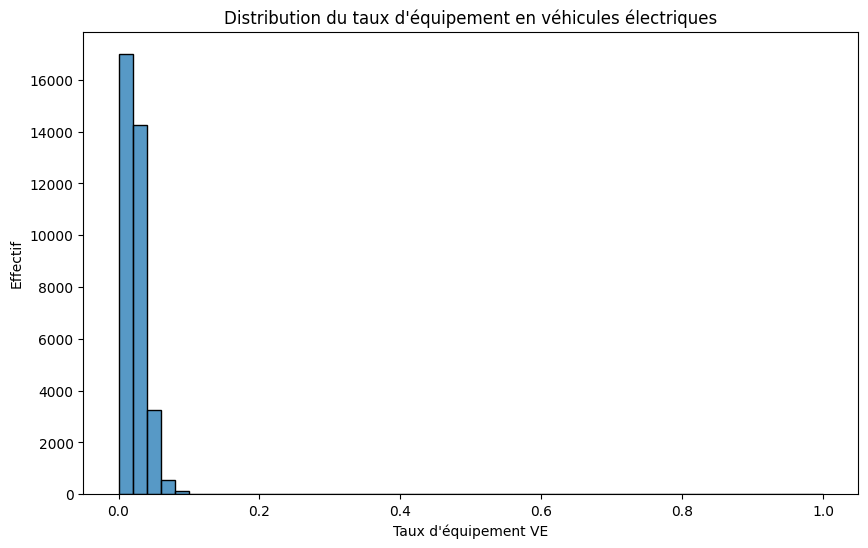

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_imputation[target], bins=50)
plt.title("Distribution du taux d'équipement en véhicules électriques")
plt.xlabel("Taux d'équipement VE")
plt.ylabel("Effectif")
plt.show()

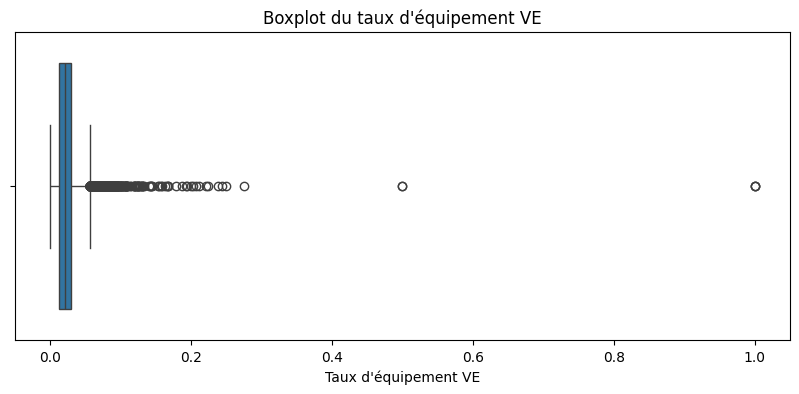

In [ ]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_imputation[target])
plt.title("Boxplot du taux d'équipement VE")
plt.xlabel("Taux d'équipement VE")
plt.show()

Le boxplot met en évidence une distribution fortement asymétrique à droite du taux d’équipement en véhicules électriques.
La majorité des communes présentent des taux faibles, tandis qu’un nombre limité d’observations affiche des valeurs élevées, générant de nombreux points extrêmes.
Ces valeurs élevées ne traduisent pas nécessairement des anomalies, mais peuvent s’expliquer par des effets de petite taille de population ou par des spécificités territoriales.
Afin de limiter l’influence de ces observations sur la modélisation, une transformation logarithmique de la variable cible sera envisagée.

In [ ]:
#df_imputation["log_taux_equipement_ve"] = np.log1p(df_imputation["taux_equipement_ve"])

## Analyse des variables explicatives

In [ ]:
# Variables à exclure (identifiants / non pertinentes)
cols_to_exclude = ["CODGEO", "Libellé géographique", target]

# Variables numériques explicatives
num_cols = [
    col for col in df_imputation.select_dtypes(include=["number"]).columns
    if col not in cols_to_exclude
]

# Variables qualitatives
cat_cols = [
    col for col in df_imputation.select_dtypes(include=["object"]).columns
    if col not in ["CODGEO", "Libellé géographique"]
]

print("Variables numériques :", num_cols)
print("\nVariables qualitatives :", cat_cols)

Variables numériques : ['NB_VP', 'NB_VP_RECHARGEABLES_EL', 'total_pdc', 'puissance_moyenne', 'puissance_max', 'nb_operateurs', 'pct_type_2', 'pct_combo_ccs', 'pct_type_ef', 'pct_paiement_cb', 'pct_paiement_autre', 'part_charge_rapide', 'prive', 'public', 'rapide', 'voirie', '[DISP] Médiane (€)', '[DISP] Nbre de ménages fiscaux', '[DISP] Nbre de personnes dans les ménages fiscaux']

Variables qualitatives : ['top_operateur']


Regardons si des variables numériques ont peu de modalités alors nous pouvons les considérer comme qualitatives :

In [ ]:
df_imputation.nunique().sort_values()

nb_operateurs                                           34
puissance_max                                           91
top_operateur                                          157
rapide                                                 387
pct_paiement_autre                                     476
public                                                 483
voirie                                                 513
pct_type_ef                                            532
pct_paiement_cb                                        545
part_charge_rapide                                     558
prive                                                  569
pct_combo_ccs                                          579
pct_type_2                                             593
total_pdc                                              623
NB_VP_RECHARGEABLES_EL                                1004
[DISP] Médiane (€)                                    1831
puissance_moyenne                                     18

Nous gardons les variables ainsi

Analyse univariée des variables numériques

In [ ]:
desc = df_imputation[num_cols].describe().T

desc["missing_pct"] = df_imputation[num_cols].isna().mean() * 100
desc["skewness"] = df_imputation[num_cols].skew()

display(desc.sort_values("missing_pct", ascending=False))

,count,mean,std,min,25%,50%,75%,max,missing_pct,skewness
part_charge_rapide,5219.0,0.214536,0.303965,0.0,0.0,0.0,0.428571,1.0,85.175822,1.146601
[DISP] Médiane (€),19356.0,23349.973652,3230.531403,13280.0,21340.0,22880.0,24830.000000,54120.0,45.020735,1.504950
[DISP] Nbre de personnes dans les ménages fiscaux,19356.0,2244.563391,9152.663422,78.0,260.0,567.0,1408.000000,420447.0,45.020735,17.722967
[DISP] Nbre de ménages fiscaux,19356.0,1006.244110,4438.451795,36.0,114.0,242.0,603.250000,222023.0,45.020735,20.142149
total_pdc,35206.0,24.149321,589.057195,0.0,0.0,0.0,0.000000,93804.0,0.000000,121.099684
NB_VP,35206.0,2028.941601,7936.071844,1.0,247.0,550.0,1356.750000,415083.0,0.000000,17.608545
NB_VP_RECHARGEABLES_EL,35206.0,64.246151,395.328601,0.0,4.0,11.0,34.000000,31298.0,0.000000,32.402890
puissance_moyenne,35206.0,9.674895,114.192459,0.0,0.0,0.0,0.000000,7360.0,0.000000,49.283166
puissance_max,35206.0,24.025568,382.731883,0.0,0.0,0.0,0.000000,50000.0,0.000000,72.754471
nb_operateurs,35206.0,0.398142,1.520193,0.0,0.0,0.0,0.000000,40.0,0.000000,8.670584


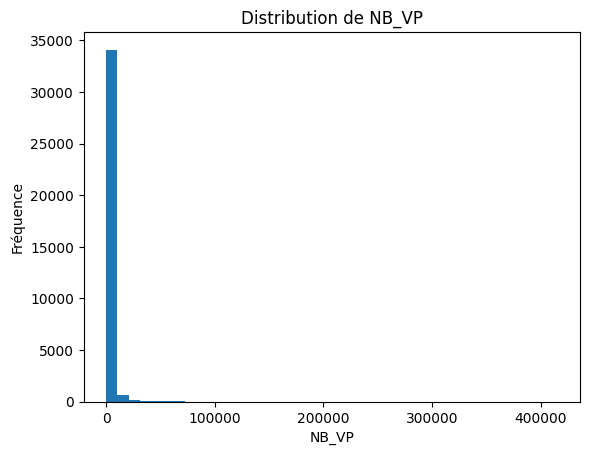

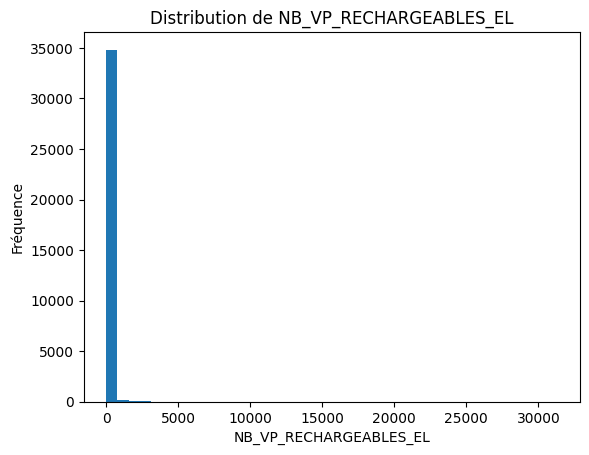

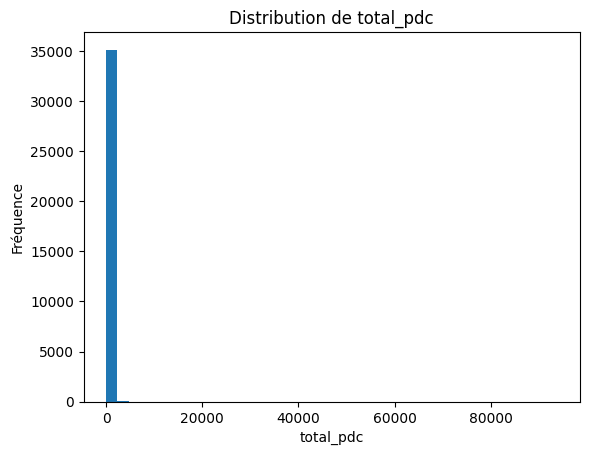

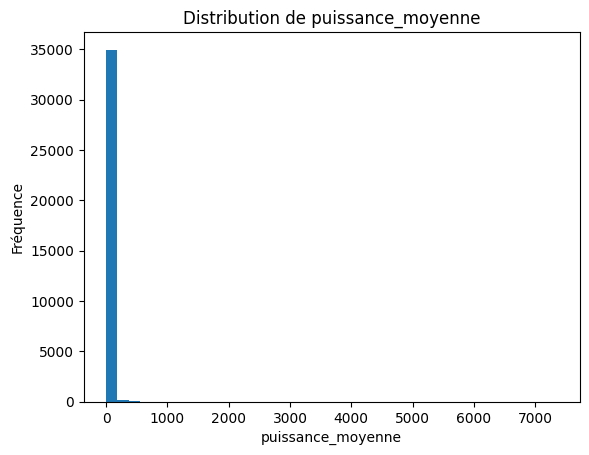

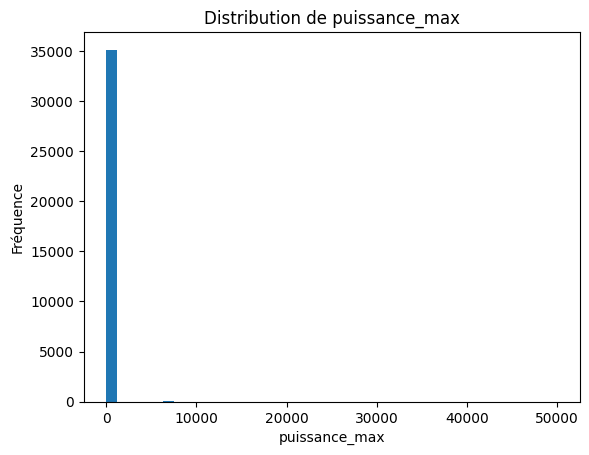

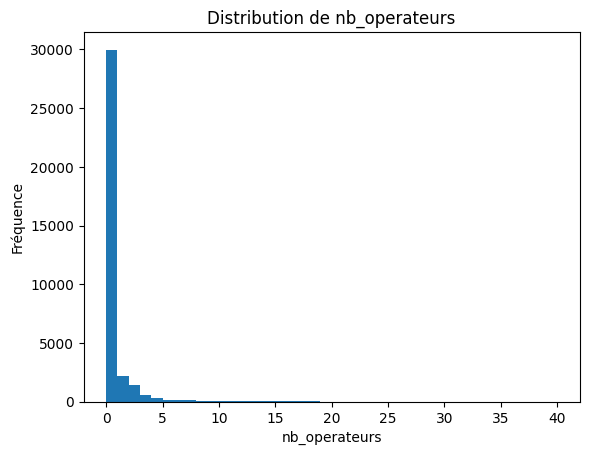

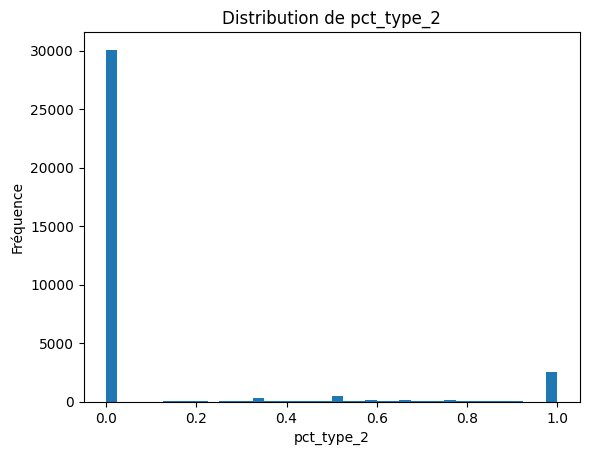

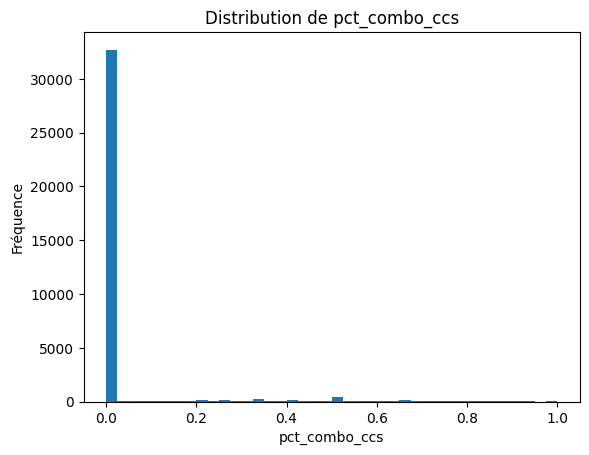

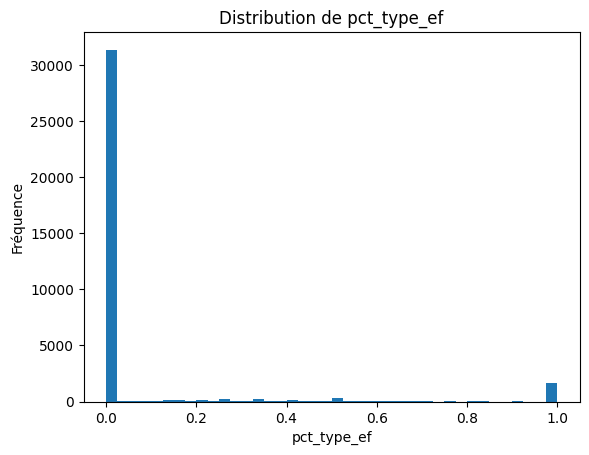

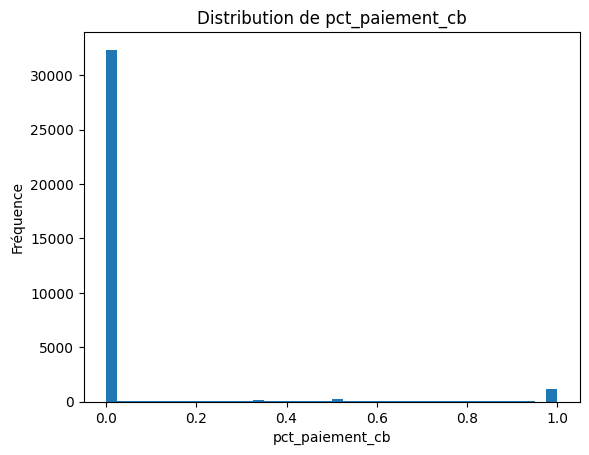

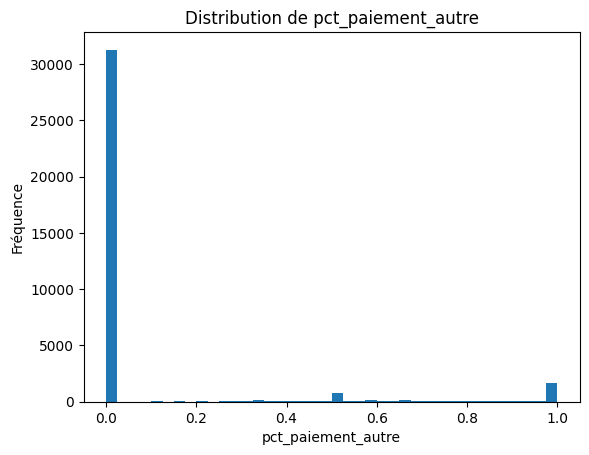

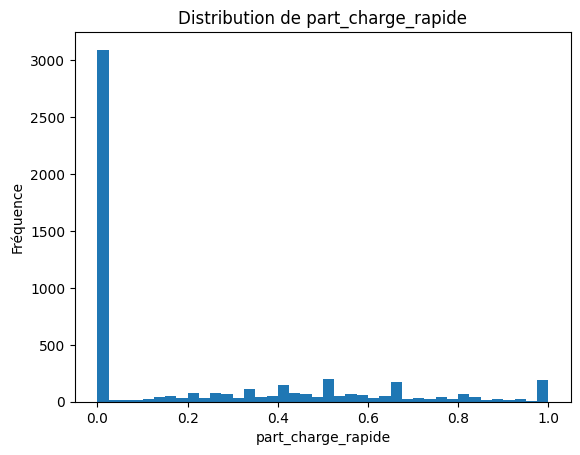

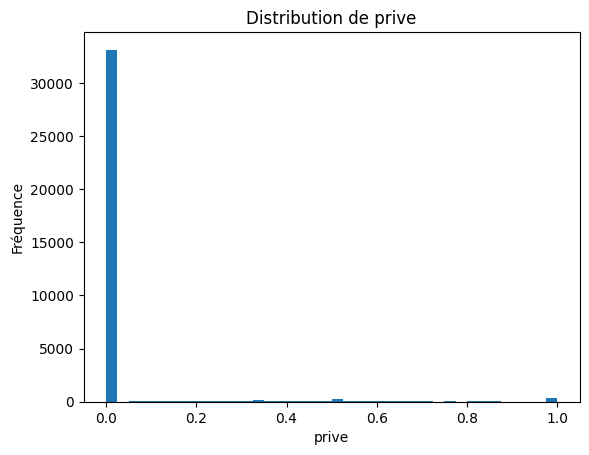

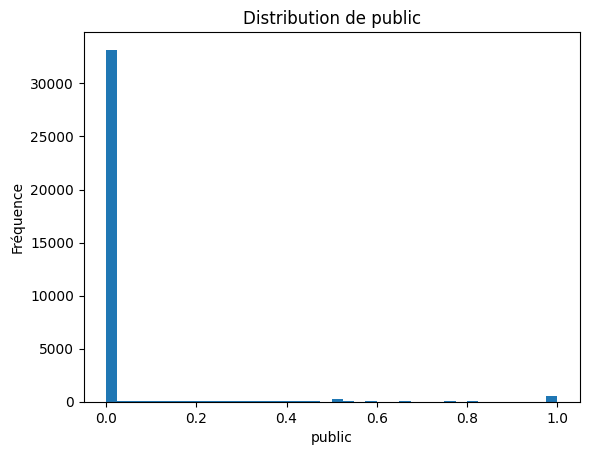

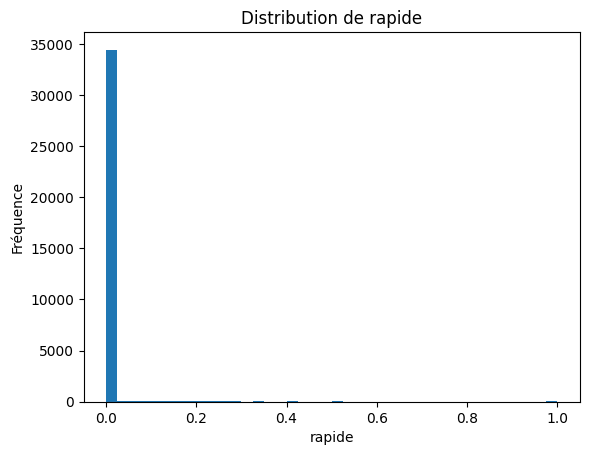

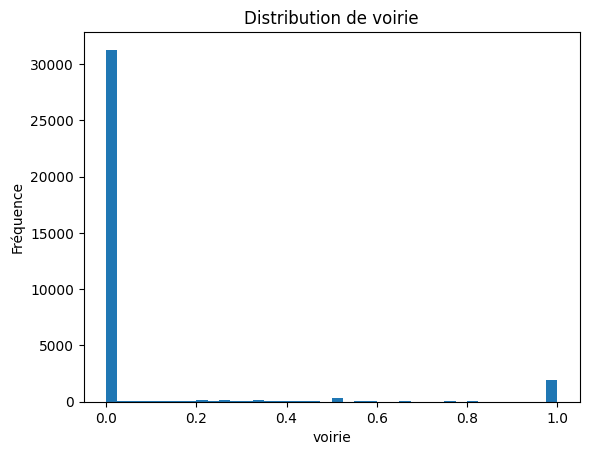

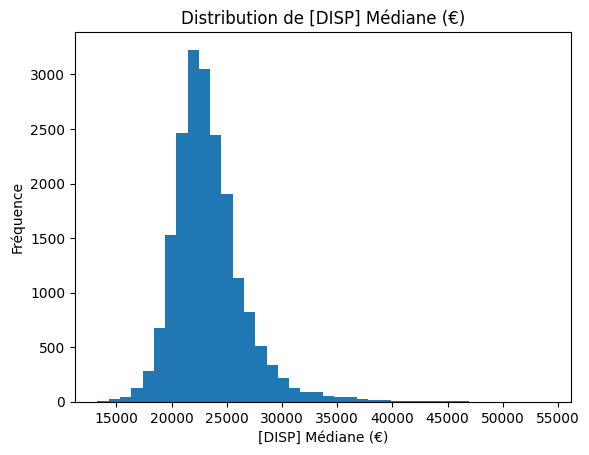

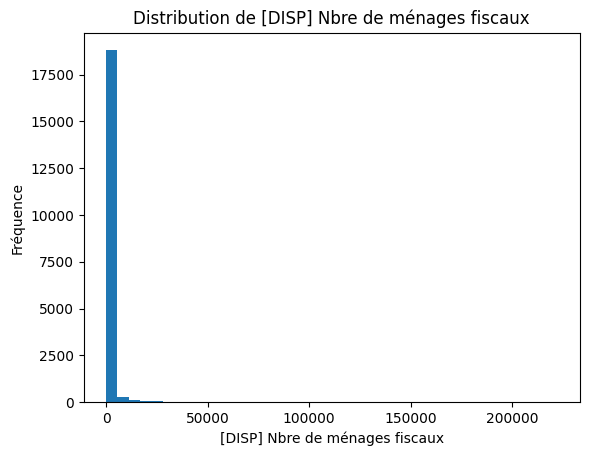

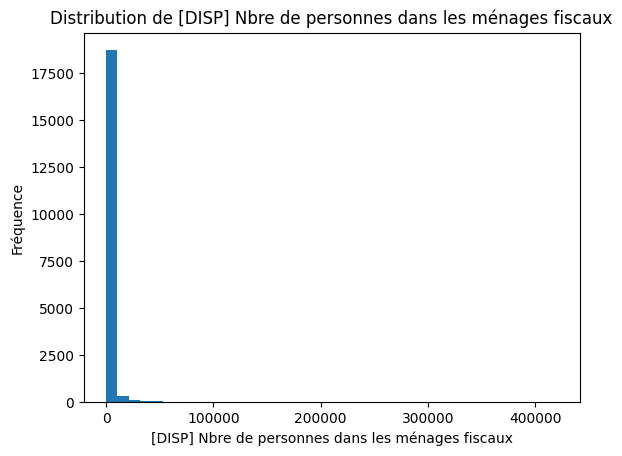

In [ ]:
for col in num_cols:
    plt.figure()
    plt.hist(df_imputation[col].dropna(), bins=40)
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.show()

### Analyse univariée des variables qualitatives

In [ ]:
for col in cat_cols:
    print(f"\n--- {col} ---")
    display(df_imputation[col].value_counts(dropna=False))


--- top_operateur ---


top_operateur
NaN                             29987
Bouygues Energies & Services      986
EASYCHARGE                        414
Freshmile | FR*FR1                396
inconnu                           366
                                ...  
Fuzed | FR*FZD                      1
La jardinerie d'aveze sarl          1
AUTORECHARGE SAS                    1
Normatech                           1
LUMI'IN                             1
Name: count, Length: 158, dtype: int64

Cette variable risque d'être retravaillée car beaucoup de NA et importance avec la variable cible

### Analyses bivariées avec la cible

Variables numériques vs cible

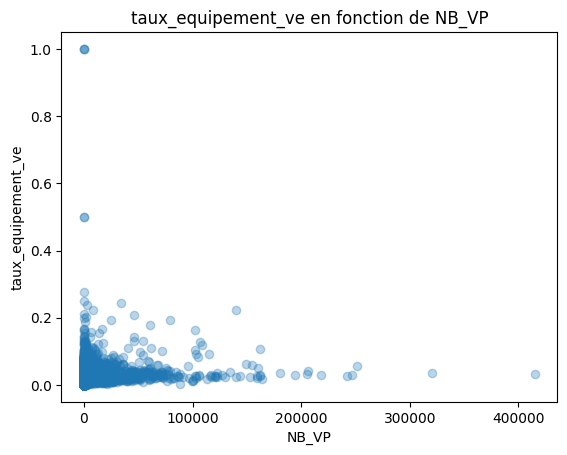

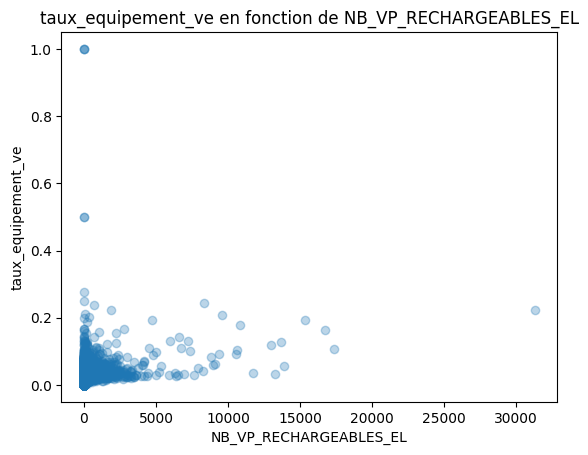

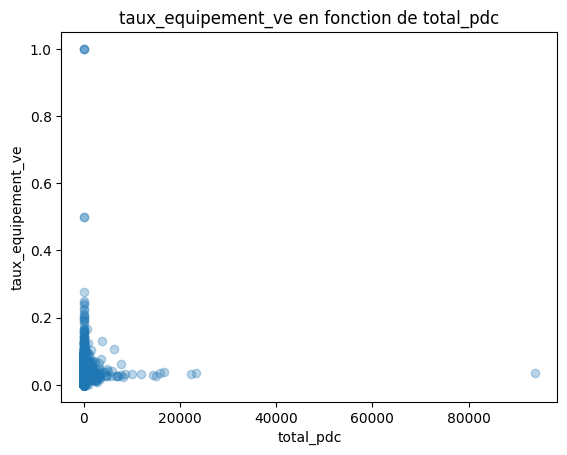

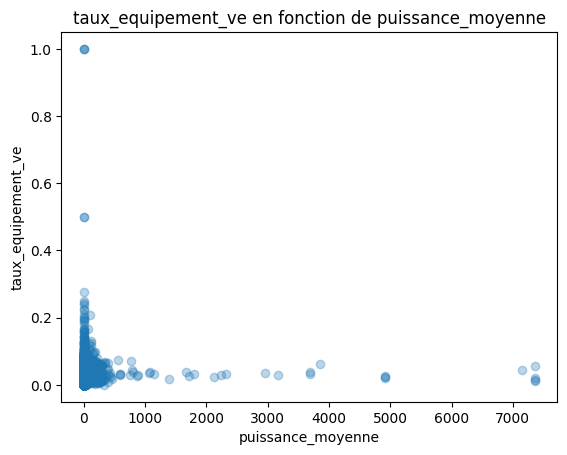

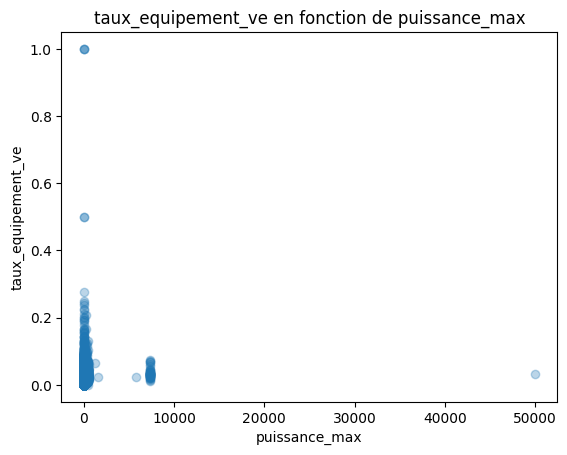

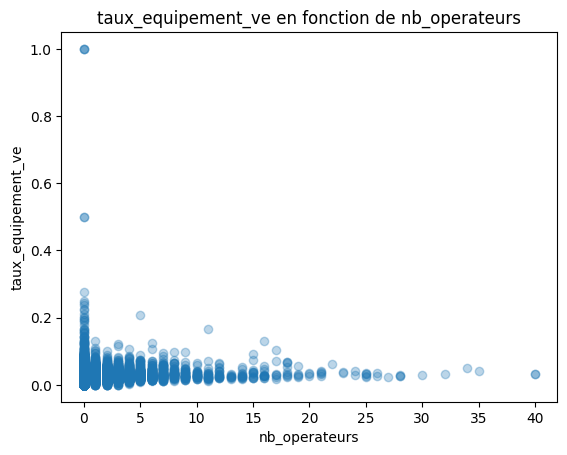

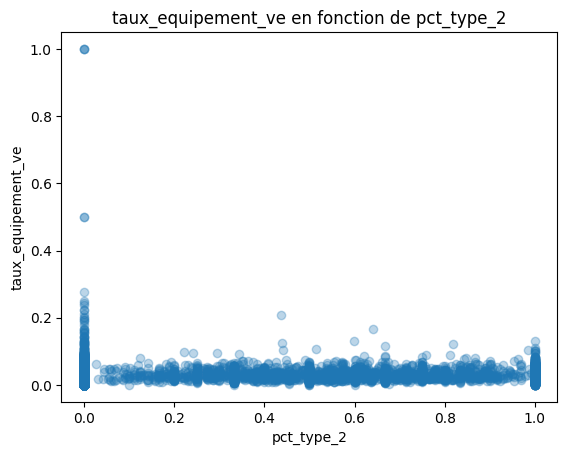

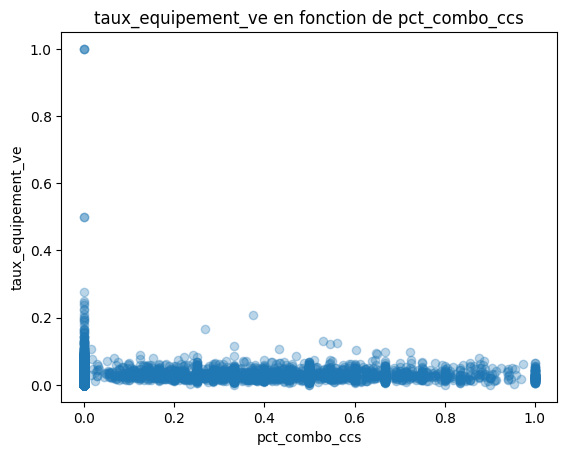

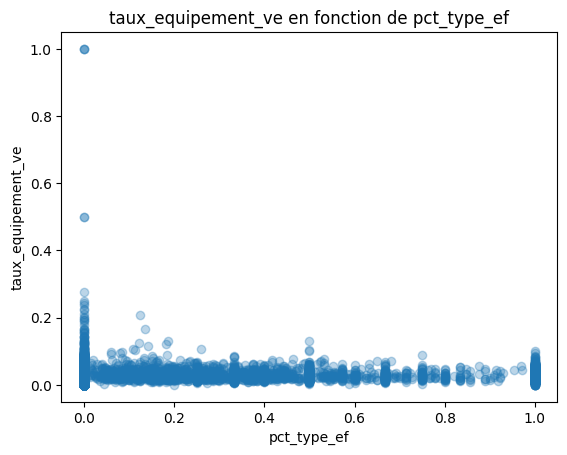

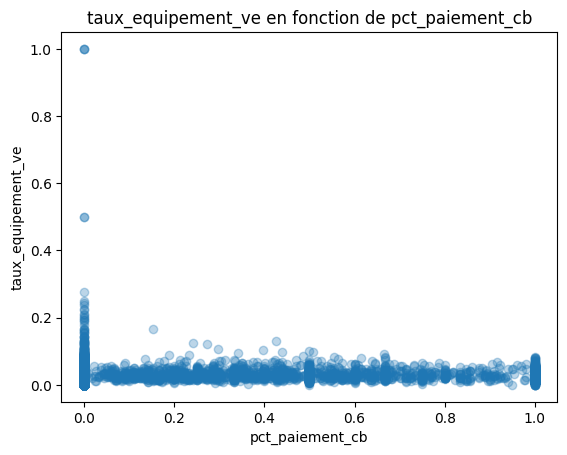

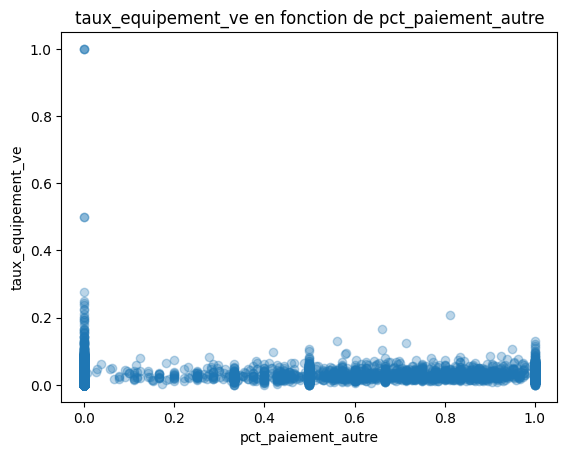

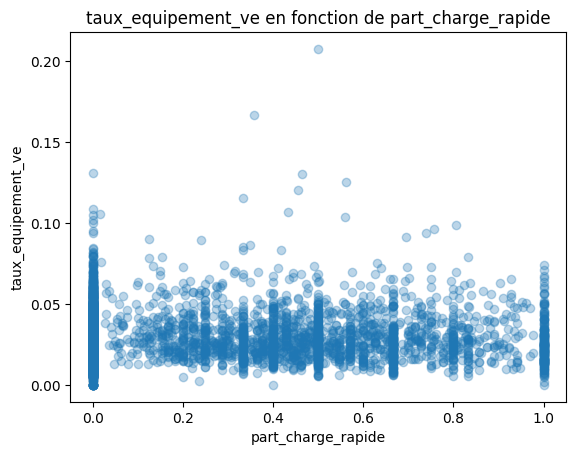

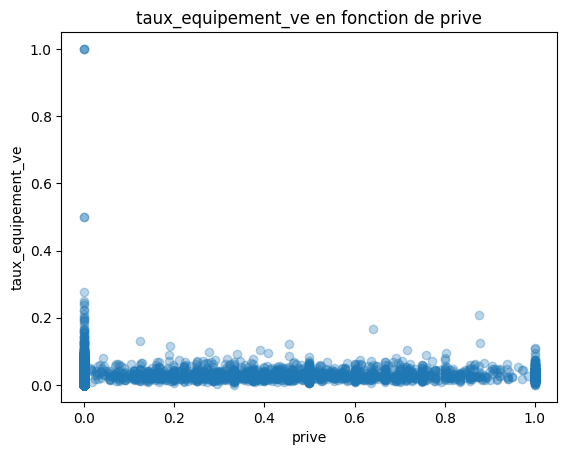

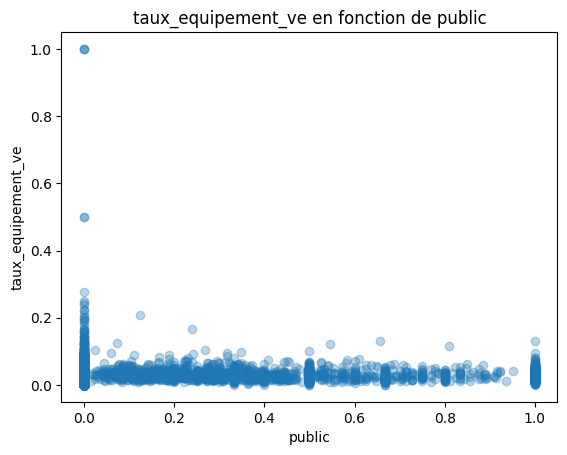

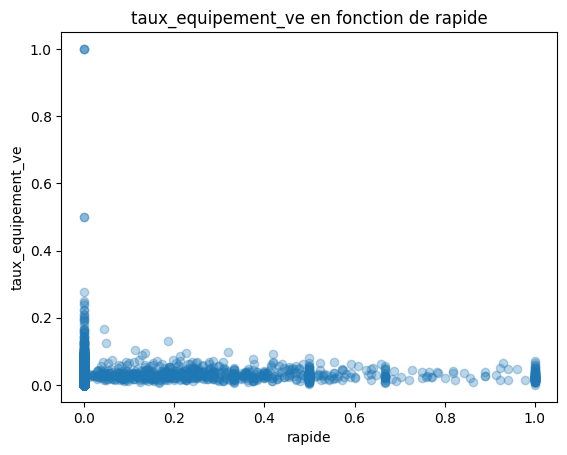

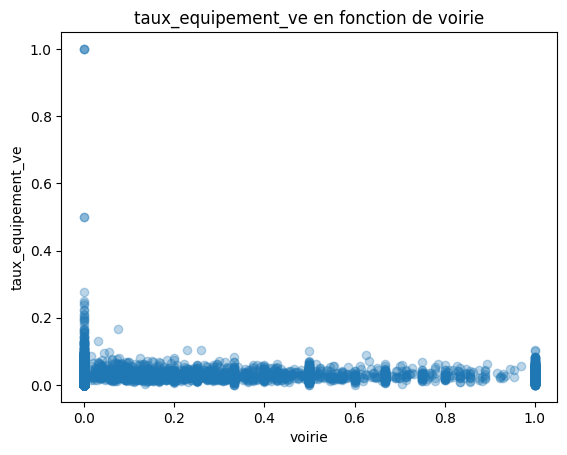

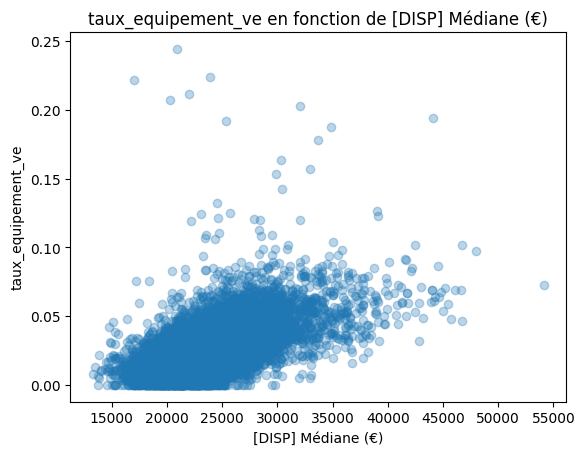

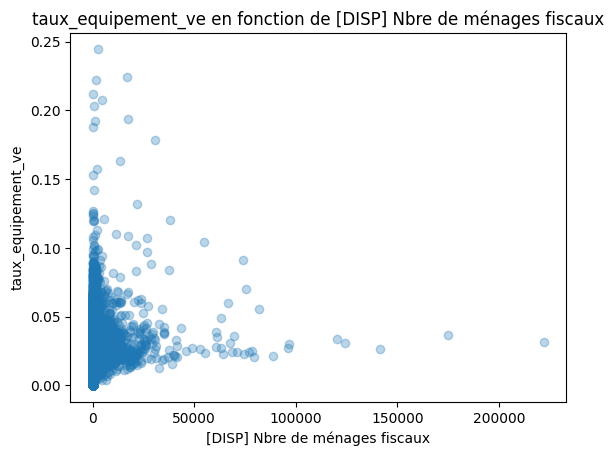

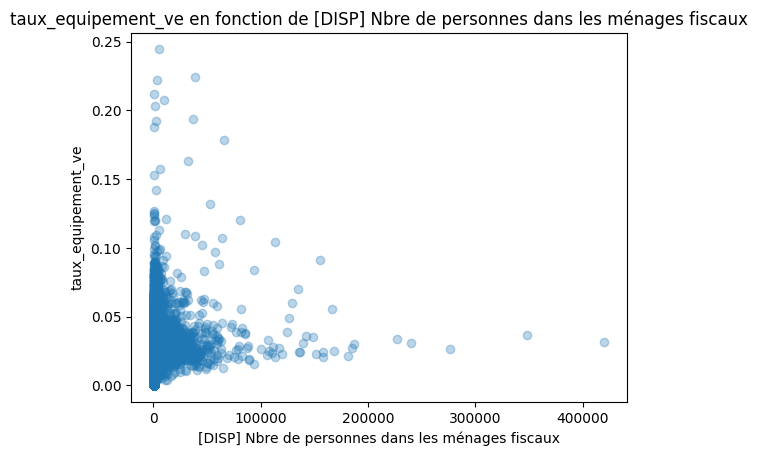

In [ ]:
for col in num_cols:
    plt.figure()
    plt.scatter(df_imputation[col], df_imputation[target], alpha=0.3)
    plt.title(f"{target} en fonction de {col}")
    plt.xlabel(col)
    plt.ylabel(target)
    plt.show()

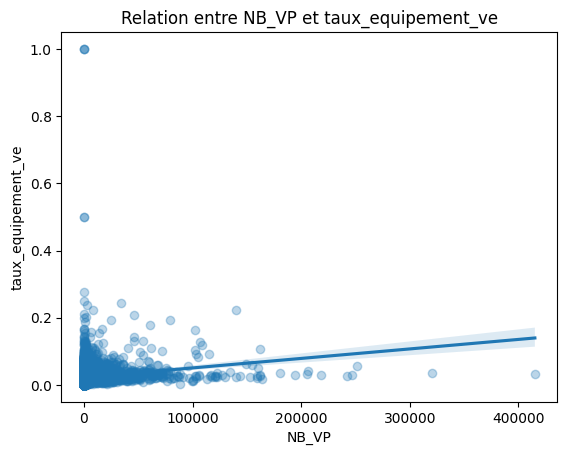

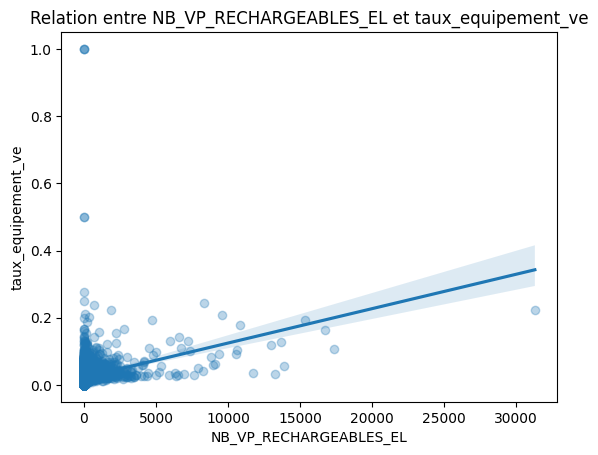

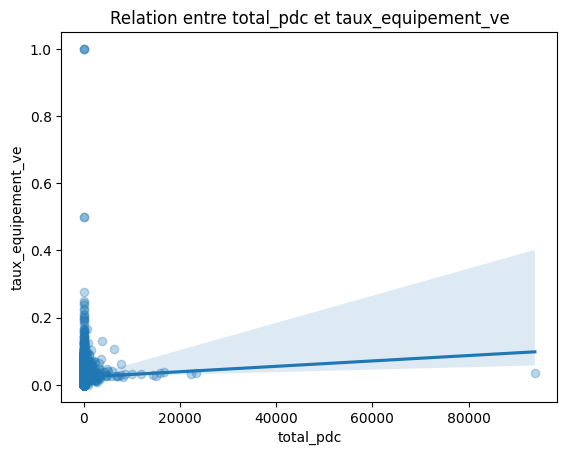

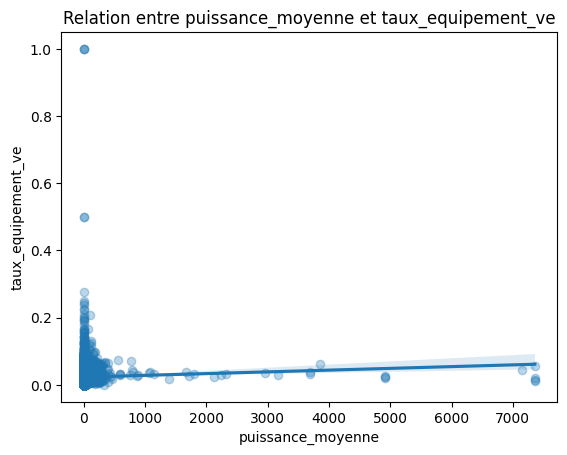

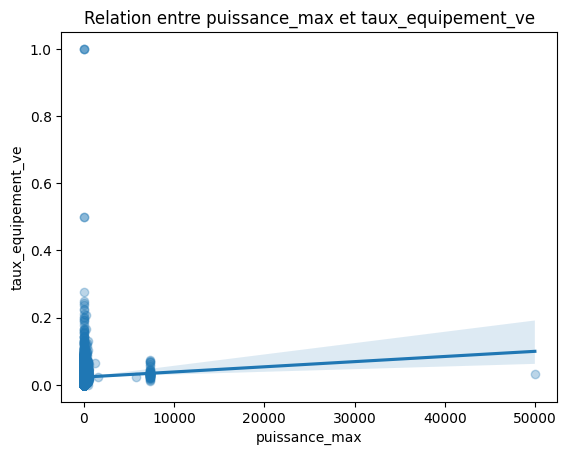

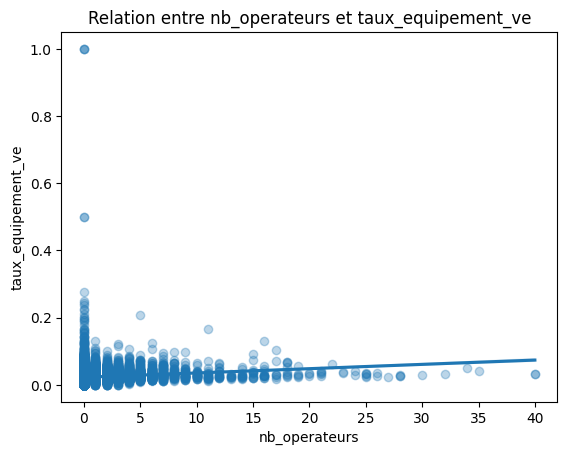

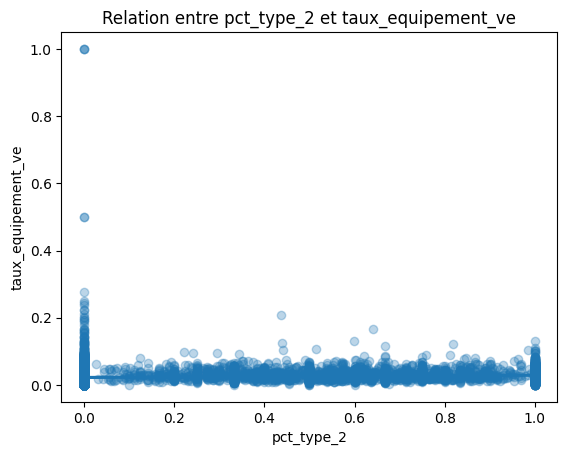

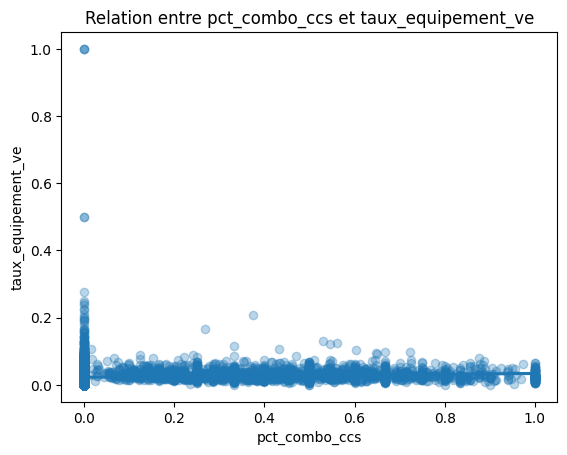

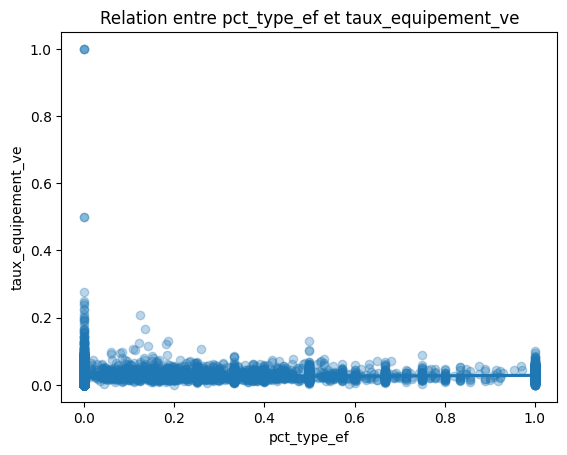

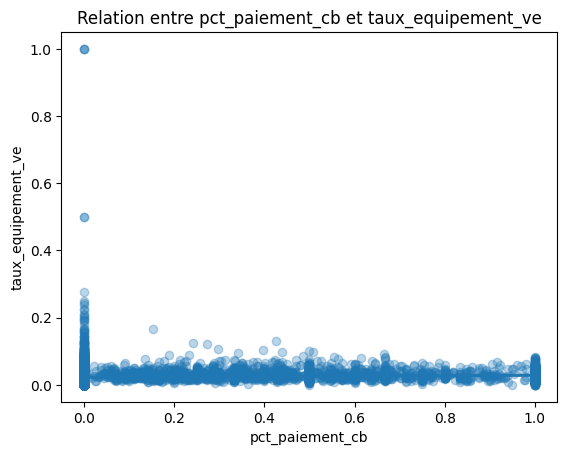

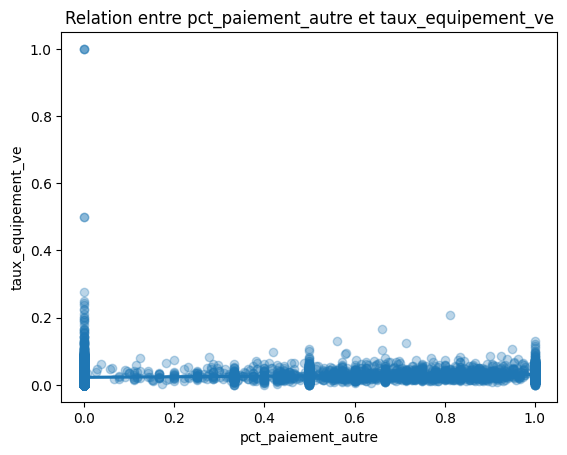

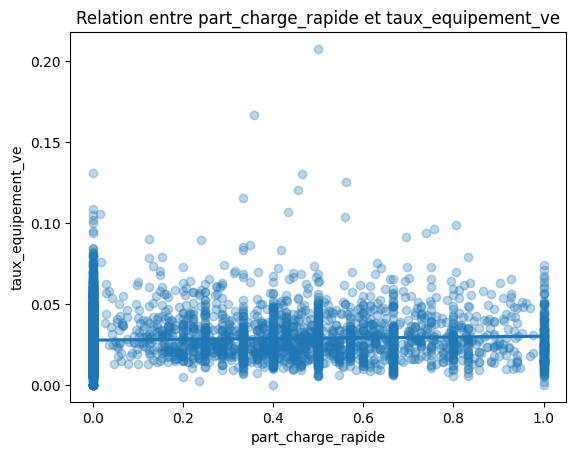

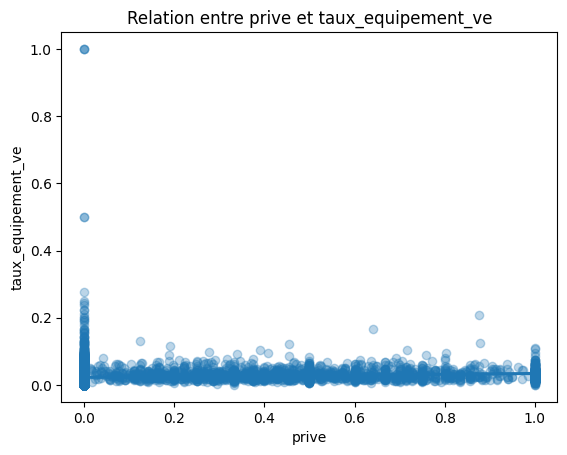

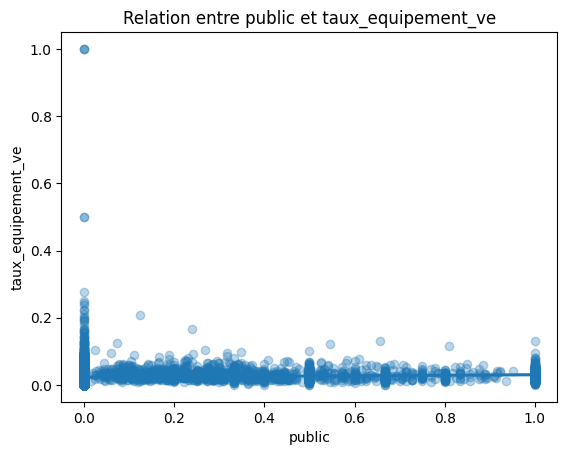

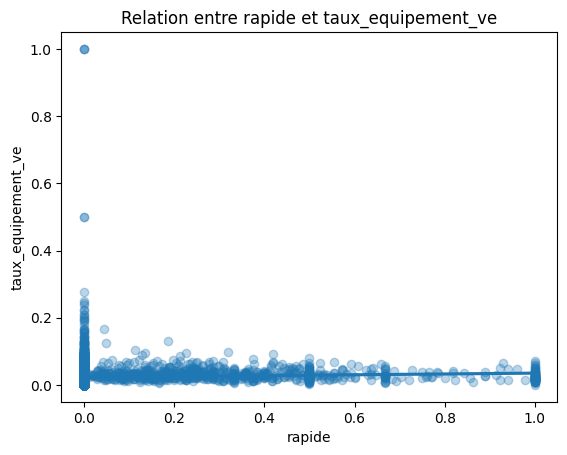

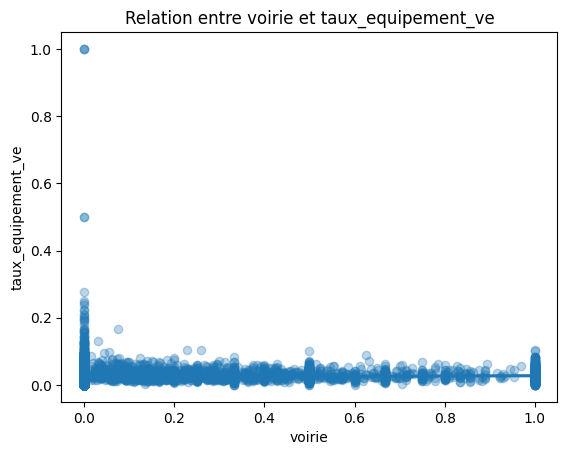

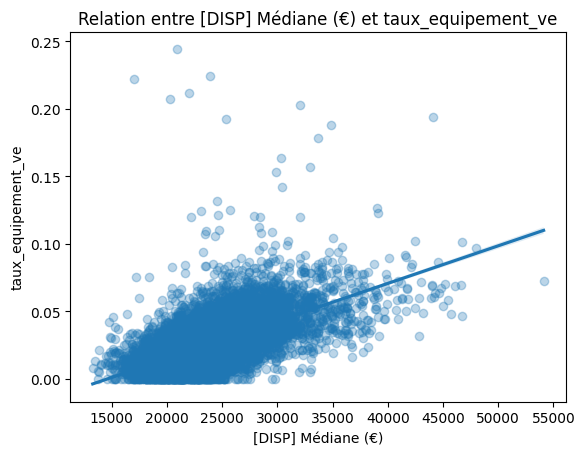

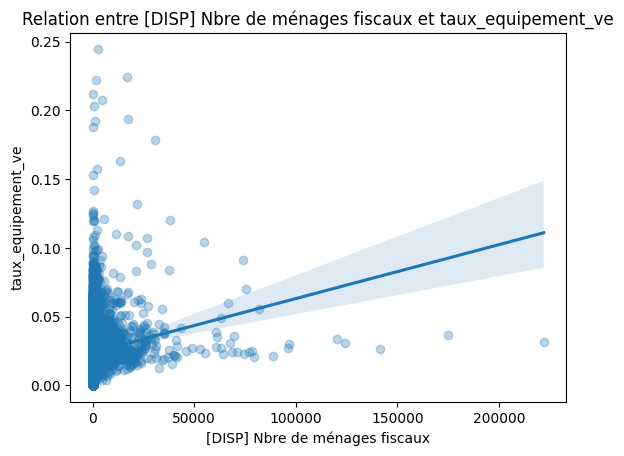

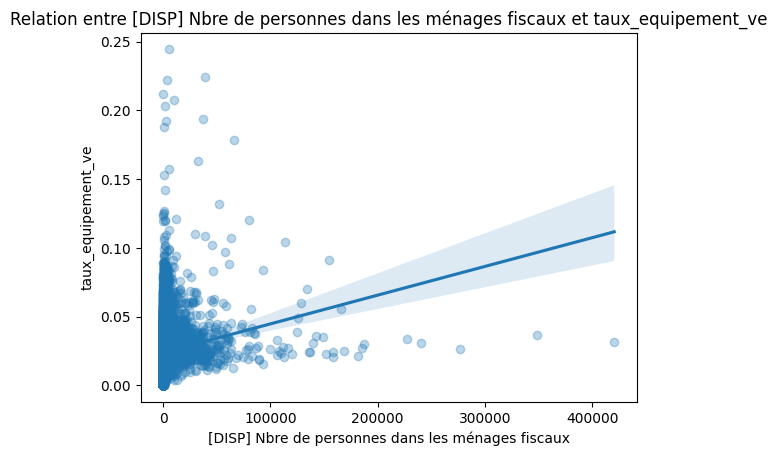

In [ ]:
for col in num_cols:
    plt.figure()
    sns.regplot(x=df_imputation[col], y=df_imputation[target], scatter_kws={"alpha": 0.3})
    plt.title(f"Relation entre {col} et {target}")
    plt.show()

Variables qualitatives vs cible

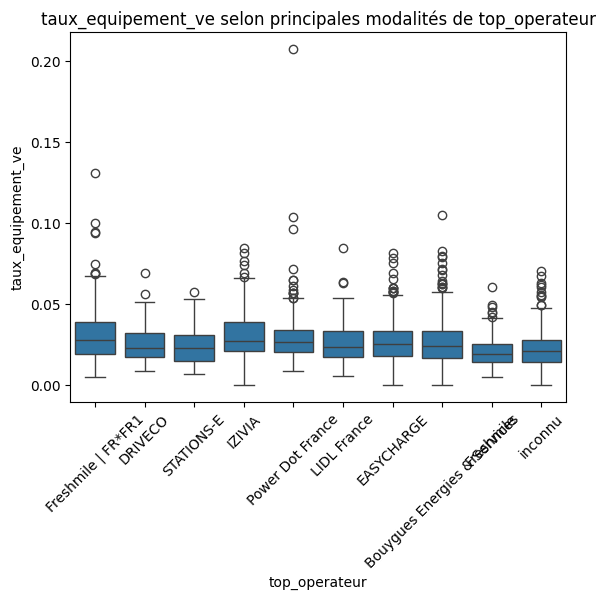

In [ ]:
for col in cat_cols:
    top = df_imputation[col].value_counts().head(10).index
    df_temp = df_imputation[df_imputation[col].isin(top)]
    
    plt.figure()
    sns.boxplot(x=df_temp[col], y=df_temp[target])
    plt.title(f"{target} selon principales modalités de {col}")
    plt.xticks(rotation=45)
    plt.show()

### Corrélations

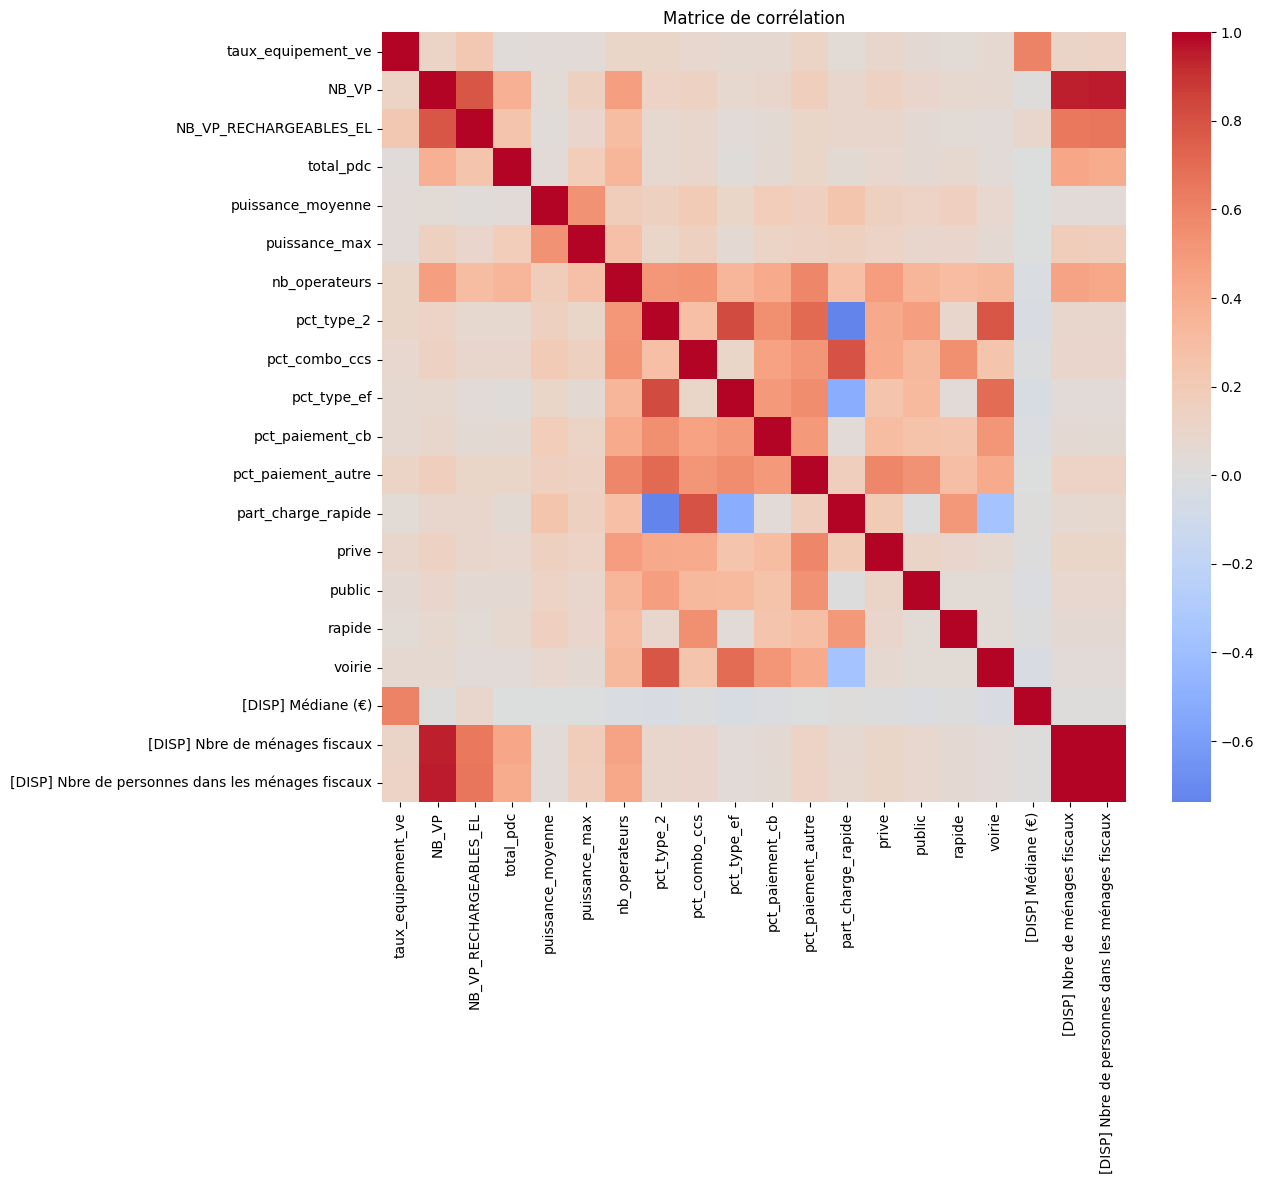

In [ ]:
corr = df_imputation[[target] + num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation")
plt.show()

Ce que nous enseigne la matrice de corrélation :
Le taux VE dépend surtout :
- de la richesse ( plus une ville est riche, plus elle semble compter des VE )
- du volume de véhicules ( Plus une ville compte de véhicules, plus elle semble compter des VE )

Les infrastructures semblent peu expliquer directement, elles suivent la demande.

Des variables sont redondentes donc peuvent être éliminées.

Corrélations avec la cible

In [ ]:
corr_target = corr[target].sort_values(ascending=False)
display(corr_target)

taux_equipement_ve                                   1.000000
[DISP] Médiane (€)                                   0.603772
NB_VP_RECHARGEABLES_EL                               0.222431
[DISP] Nbre de personnes dans les ménages fiscaux    0.128367
NB_VP                                                0.123340
pct_paiement_autre                                   0.118991
[DISP] Nbre de ménages fiscaux                       0.116822
nb_operateurs                                        0.106787
pct_type_2                                           0.105569
prive                                                0.093344
pct_combo_ccs                                        0.081265
pct_type_ef                                          0.069451
voirie                                               0.065512
pct_paiement_cb                                      0.065254
public                                               0.061972
part_charge_rapide                                   0.048968
rapide  

Nous pouvons voir une forme d'explication avec certains groupes de variables comme celles socio démographiques. Un tri va être opéré pour une meilleure lisibilité.

Multicolinéarité

In [ ]:
corr_expl = df_imputation[num_cols].corr().abs()

upper = corr_expl.where(np.triu(np.ones(corr_expl.shape), k=1).astype(bool))

high_corr = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "var1", "level_1": "var2", 0: "corr"})
    .sort_values("corr", ascending=False)
)

display(high_corr[high_corr["corr"] > 0.8])

,var1,var2,corr
170,[DISP] Nbre de ménages fiscaux,[DISP] Nbre de personnes dans les ménages fiscaux,0.993889
17,NB_VP,[DISP] Nbre de personnes dans les ménages fiscaux,0.952585
16,NB_VP,[DISP] Nbre de ménages fiscaux,0.945046
94,pct_type_2,pct_type_ef,0.820462
108,pct_combo_ccs,part_charge_rapide,0.800563


Nous choisissons une variable représentative des groupes de variables mis en évidence :

In [ ]:
vars_to_drop = [
    "NB_VP",
    "NB_VP_RECHARGEABLES_EL",
    "[DISP] Nbre de ménages fiscaux",
    "pct_type_2",
    "pct_type_ef",
    "part_charge_rapide"
]

df_clean = df_imputation.drop(columns=vars_to_drop, errors="ignore")

La variable cible étant construite comme un ratio entre le nombre de véhicules électriques et le nombre total de véhicules, les variables utilisées pour sa construction ont été exclues de l’analyse afin d’éviter tout biais de fuite d’information.
Leur inclusion aurait conduit à une relation mécanique avec la variable cible, faussant ainsi l’interprétation des résultats.

In [ ]:
df_clean

,CODGEO,taux_equipement_ve,total_pdc,puissance_moyenne,puissance_max,nb_operateurs,pct_combo_ccs,pct_paiement_cb,pct_paiement_autre,top_operateur,prive,public,rapide,voirie,Libellé géographique,[DISP] Médiane (€),[DISP] Nbre de personnes dans les ménages fiscaux
0,1002,0.017483,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN
1,1004,0.032214,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN
2,1005,0.029488,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN
3,1007,0.032400,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,1009,0.022075,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35201,97612,0.003136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN
35202,97615,0.001649,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN
35203,97699,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN
35204,97801,0.042105,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN


In [ ]:
missing_pct = df_clean.isna().mean() * 100
display(missing_pct.sort_values(ascending=False))

top_operateur                                        85.175822
[DISP] Médiane (€)                                   45.020735
[DISP] Nbre de personnes dans les ménages fiscaux    45.020735
Libellé géographique                                 39.248992
CODGEO                                                0.000000
taux_equipement_ve                                    0.000000
total_pdc                                             0.000000
puissance_moyenne                                     0.000000
puissance_max                                         0.000000
pct_paiement_autre                                    0.000000
pct_paiement_cb                                       0.000000
pct_combo_ccs                                         0.000000
nb_operateurs                                         0.000000
rapide                                                0.000000
public                                                0.000000
prive                                                 0

In [ ]:
df_clean.to_csv("data/df_clean.csv", index=False)